# AHP 層級分析法：計算原理、數學推導與 Python 實作

本 Notebook 以「AHP 計算原理與數學推導教材」為藍本，將原本的 Markdown 教材整理成可執行的 Jupyter Notebook。

本教材分成三個部分：

1. AHP 的基本概念與數學推導。
2. Vanilla Python / NumPy 版本：從矩陣開始自行計算權重、最大特徵值、CI 與 CR。
3. 套件版本：示範使用 Python AHP 套件 `ahpy` 進行同一組資料的計算。

> 說明：AHP 的核心在於將主觀的成對比較轉換為可檢查一致性的權重，因此本 Notebook 會刻意保留中間計算步驟，而不是只輸出最後結果。


## 0. 環境設定

本 Notebook 的 vanilla 版本只需要 `numpy` 與 `pandas`。

套件版本會使用 `ahpy`。如果尚未安裝，可先執行下列安裝指令：

```python
%pip install ahpy
```

若你是在本機教學環境中使用，建議先用虛擬環境或 conda environment 管理套件。


以下內容保留原始教材的主要章節，並轉換為 Notebook 的 Markdown 說明。

# AHP 計算原理與數學推導教材

## 1. AHP 是什麼？

層級分析法（Analytic Hierarchy Process, AHP）是由 Thomas L. Saaty 提出的一種多準則決策方法，主要用來處理具有多個評估準則、多個可行方案，且部分因素難以直接量化的決策問題。

AHP 的核心概念是：

1. 將複雜問題拆解成層級結構。
2. 透過成對比較取得決策者對各準則的相對重要性判斷。
3. 將主觀判斷轉換為可計算的權重。
4. 檢查判斷是否具有一致性。
5. 根據權重進行方案排序或決策分析。

例如在智慧型手錶選購問題中，消費者可能同時考量價格、續航力、健康監測功能、品牌、外觀設計與使用便利性。這些因素不能只用單一指標判斷，因此適合使用 AHP 進行分析。

---

## 2. AHP 的層級結構

AHP 通常會將決策問題拆成三個層級：

| 層級 | 說明 | 範例 |
|---|---|---|
| 目標層 | 最終決策目標 | 選出最適合的智慧型手錶 |
| 準則層 | 評估方案的重要因素 | 價格、續航力、健康監測功能 |
| 方案層 | 可選擇的替代方案 | Apple Watch、Galaxy Watch、Garmin |

簡化後的層級架構如下：

```text
目標：選擇最適合的智慧型手錶
│
├── 價格
├── 續航力
└── 健康監測功能
    │
    ├── 方案 A
    ├── 方案 B
    └── 方案 C
```

---

## 3. AHP 的基本假設

AHP 建立在幾個重要假設之上。

### 3.1 交互性假設（Reciprocity）

若準則 $i$ 相對於準則 $j$ 的重要程度為：

$$
a_{ij}
$$

則準則 $j$ 相對於準則 $i$ 的重要程度為：

$$
a_{ji}=\frac{1}{a_{ij}}
$$

例如，若「續航力」比「價格」重要 3 倍，則「價格」相對於「續航力」的重要程度就是 $1/3$。

### 3.2 同質性假設（Homogeneity）

同一層級中的要素應具有可比較性。例如可以在同一層比較價格、續航力與健康監測功能，但若項目差異太大，則需要重新檢查層級分類是否合理。

### 3.3 依賴性假設（Dependency）

上層目標會支配下層準則，下層準則則用來評估方案。例如「選擇智慧型手錶」這個目標會往下拆成價格、續航力、健康監測功能等準則。

### 3.4 完整性假設（Expectations）

層級結構應盡可能納入與決策相關的重要因素。如果遺漏重要準則，後續權重與排序結果就可能失真。

---

## 4. 成對比較與 AHP 尺度

AHP 不是要求決策者一次排序所有準則，而是透過「兩兩比較」判斷重要性。

例如：

- 價格與續航力相比，哪一個比較重要？
- 續航力與健康監測功能相比，哪一個比較重要？
- 價格與健康監測功能相比，哪一個比較重要？

AHP 常用 1 至 9 尺度表示相對重要程度。

| 數值 | 意義 |
|---|---|
| 1 | 兩者同等重要 |
| 3 | 稍微重要 |
| 5 | 明顯重要 |
| 7 | 非常重要 |
| 9 | 極端重要 |
| 2、4、6、8 | 介於相鄰判斷之間 |
| 倒數 | 反向比較 |

例如：

若 $a_{12}=3$，表示準則 1 比準則 2 重要 3 倍；

若 $a_{21}=1/3$，表示準則 2 相對於準則 1 的重要程度為 $1/3$。

---

## 5. 建立成對比較矩陣

假設有 $n$ 個準則，則 AHP 的成對比較矩陣可表示為：

$$
A=
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n}\\
a_{21} & a_{22} & \cdots & a_{2n}\\
\vdots & \vdots & \ddots & \vdots\\
a_{n1} & a_{n2} & \cdots & a_{nn}
\end{bmatrix}
$$

其中 $a_{ij}$ 代表第 $i$ 個準則相對於第 $j$ 個準則的重要程度。

AHP 的判斷矩陣具有以下性質：

$$
a_{ii}=1
$$

因為每個準則與自己相比，重要程度相同。

$$
a_{ji}=\frac{1}{a_{ij}}
$$

因為反向比較值必須是原比較值的倒數。

因此，AHP 矩陣也可寫成：

$$
A=
\begin{bmatrix}
1 & a_{12} & a_{13} & \cdots & a_{1n} \\
\frac{1}{a_{12}} & 1 & a_{23} & \cdots & a_{2n} \\
\frac{1}{a_{13}} & \frac{1}{a_{23}} & 1 & \cdots & a_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\frac{1}{a_{1n}} & \frac{1}{a_{2n}} & \frac{1}{a_{3n}} & \cdots & 1
\end{bmatrix}
$$

這種矩陣稱為「互反矩陣」或「正倒值矩陣」。

---

## 6. 多位專家意見整合：幾何平均法

若研究中邀請多位專家填寫 AHP 問卷，就需要將多位專家的成對比較值整合成一個群體判斷值。

假設共有 $m$ 位專家，第 $k$ 位專家對第 $i$ 準則與第 $j$ 準則的判斷值為：

$$
a_{ij}^{(k)}
$$

則整合後的群體判斷值為：

$$
a_{ij}=\left(a_{ij}^{(1)} \times a_{ij}^{(2)} \times \cdots \times a_{ij}^{(m)}\right)^{\frac{1}{m}}
$$

也可寫成：

$$
a_{ij}=\sqrt[m]{\prod_{k=1}^{m}a_{ij}^{(k)}}
$$

### 為什麼使用幾何平均法？

AHP 的比較值屬於比例尺度資料，重點不是「差幾分」，而是「重要幾倍」。因此，比起算術平均，幾何平均更適合用來整合比例判斷。

更重要的是，幾何平均法可以維持 AHP 的相互倒數性。

例如兩位專家對 $a_{ij}$ 的判斷分別為 3 與 5，則：

$$
a_{ij}=\sqrt{3\times 5}
$$

反方向的比較值為 $1/3$ 與 $1/5$，整合後為：

$$
a_{ji}=\sqrt{\frac{1}{3}\times\frac{1}{5}}
$$

此時會滿足：

$$
a_{ji}=\frac{1}{a_{ij}}
$$

若使用算術平均，則可能破壞這種倒數關係。因此，在群體 AHP 中通常採用幾何平均法整合專家判斷。

---

## 7. 範例：建立一個 AHP 判斷矩陣

假設有三個準則：

- $C_1$：價格
- $C_2$：續航力
- $C_3$：健康監測功能

專家判斷如下：

1. 價格相對於續航力的重要性為 $1/3$，表示續航力比價格重要。
2. 價格相對於健康監測功能的重要性為 $1/5$，表示健康監測功能比價格重要。
3. 續航力相對於健康監測功能的重要性為 $1/2$，表示健康監測功能比續航力稍微重要。

因此，判斷矩陣 $A$ 為：

$$
A=
\begin{bmatrix}
1 & \frac{1}{3} & \frac{1}{5}\\
3 & 1 & \frac{1}{2}\\
5 & 2 & 1
\end{bmatrix}
$$

---

## 8. 求取權重向量

AHP 的目標是從判斷矩陣中求出各準則的權重。常見方式包含特徵向量法與幾何平均法。以下先用幾何平均法示範。

### 8.1 計算每一列的幾何平均數

第一列：

$$
GM_1=\sqrt[3]{1\times\frac{1}{3}\times\frac{1}{5}}
=\sqrt[3]{\frac{1}{15}}
\approx 0.405
$$

第二列：

$$
GM_2=\sqrt[3]{3\times 1\times\frac{1}{2}}
=\sqrt[3]{1.5}
\approx 1.145
$$

第三列：

$$
GM_3=\sqrt[3]{5\times 2\times 1}
=\sqrt[3]{10}
\approx 2.154
$$

### 8.2 標準化幾何平均數

先將幾何平均數加總：

$$
0.405+1.145+2.154=3.704
$$

接著將每一個幾何平均數除以總和：

$$
w_1=\frac{0.405}{3.704}\approx 0.109
$$

$$
w_2=\frac{1.145}{3.704}\approx 0.309
$$

$$
w_3=\frac{2.154}{3.704}\approx 0.582
$$

因此，權重向量為：

$$
w=
\begin{bmatrix}
0.109\\
0.309\\
0.582
\end{bmatrix}
$$

代表：

| 準則 | 權重 | 解釋 |
|---|---:|---|
| 價格 | 0.109 | 相對較不重要 |
| 續航力 | 0.309 | 中等重要 |
| 健康監測功能 | 0.582 | 最重要 |

---

## 9. 最大特徵值與權重向量

在 AHP 的特徵向量法中，權重向量 $w$ 與最大特徵值 $\lambda_{\max}$ 滿足：

$$
Aw=\lambda_{\max}w
$$

其中：

- $A$：成對比較矩陣
- $w$：權重向量
- $\lambda_{\max}$：最大特徵值

簡單來說，這個公式表示：從成對比較矩陣 $A$ 中找出一組最能代表整體判斷結果的權重 $w$。

最大特徵值 $\lambda_{\max}$ 除了用來求權重，也會用來檢查矩陣的一致性。

---

## 10. 範例：估算最大特徵值

已知：

$$
A=
\begin{bmatrix}
1 & \frac{1}{3} & \frac{1}{5}\\
3 & 1 & \frac{1}{2}\\
5 & 2 & 1
\end{bmatrix}
$$

$$
w=
\begin{bmatrix}
0.109\\
0.309\\
0.582
\end{bmatrix}
$$

先計算：

$$
Aw=
\begin{bmatrix}
1 & \frac{1}{3} & \frac{1}{5}\\
3 & 1 & \frac{1}{2}\\
5 & 2 & 1
\end{bmatrix}
\begin{bmatrix}
0.109\\
0.309\\
0.582
\end{bmatrix}
$$

計算結果約為：

$$
Aw=
\begin{bmatrix}
0.329\\
0.927\\
1.746
\end{bmatrix}
$$

再將 $Aw$ 的每一個元素除以對應的權重：

$$
\frac{0.329}{0.109}\approx 3.018
$$

$$
\frac{0.927}{0.309}\approx 3.000
$$

$$
\frac{1.746}{0.582}\approx 3.000
$$

最後取平均：

$$
\lambda_{\max}=\frac{3.018+3.000+3.000}{3}\approx 3.006
$$

因此，本例的最大特徵值約為：

$$
\lambda_{\max}\approx 3.006
$$

---

## 11. 一致性檢定

AHP 使用專家或受測者的主觀判斷，因此可能出現前後不一致的情況。

例如，若某人認為：

$$
C_1 \text{ 比 } C_2 \text{ 重要 3 倍}
$$

$$
C_2 \text{ 比 } C_3 \text{ 重要 2 倍}
$$

則理論上：

$$
C_1 \text{ 應約比 } C_3 \text{ 重要 } 3\times 2=6 \text{ 倍}
$$

如果實際填答時卻認為 $C_1$ 只比 $C_3$ 重要 2 倍，則代表判斷可能不一致。

因此，AHP 需要進行一致性檢定。

---

## 12. 一致性指標 CI

一致性指標（Consistency Index, CI）計算公式為：

$$
CI=\frac{\lambda_{\max}-n}{n-1}
$$

其中：

- $\lambda_{\max}$：最大特徵值
- $n$：準則數量

若矩陣完全一致，則：

$$
\lambda_{\max}=n
$$

因此：

$$
CI=0
$$

若 $\lambda_{\max}$ 明顯大於 $n$，則表示判斷矩陣存在較高程度的不一致。

---

## 13. 隨機指標 RI

隨機指標（Random Index, RI）是 Saaty 提供的參考值，用來表示不同矩陣大小下，隨機產生矩陣的平均一致性程度。

常見 RI 值如下：

| $n$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| RI | 0.00 | 0.00 | 0.58 | 0.90 | 1.12 | 1.24 | 1.32 | 1.41 | 1.45 | 1.49 |

---

## 14. 一致性比例 CR

一致性比例（Consistency Ratio, CR）計算公式為：

$$
CR=\frac{CI}{RI}
$$

一般判斷標準為：

$$
CR<0.10
$$

表示矩陣具有可接受的一致性。

若：

$$
CR\geq 0.10
$$

則表示判斷矩陣一致性不足，可能需要請專家或受測者重新檢視成對比較結果。

---

## 15. 範例：計算 CI 與 CR

前面已求得：

$$
\lambda_{\max}=3.006
$$

準則數量為：

$$
n=3
$$

因此：

$$
CI=\frac{3.006-3}{3-1}
=\frac{0.006}{2}
=0.003
$$

當 $n=3$ 時：

$$
RI=0.58
$$

因此：

$$
CR=\frac{0.003}{0.58}\approx 0.005
$$

由於：

$$
0.005<0.10
$$

所以此判斷矩陣具有良好一致性，可以接受。

---

## 16. AHP 計算流程總結

AHP 的完整計算流程可整理如下：

1. 建立決策層級架構。
2. 針對同一層級準則進行成對比較。
3. 建立成對比較矩陣。
4. 若有多位專家，使用幾何平均法整合判斷值。
5. 求取各準則權重。
6. 求取最大特徵值 $\lambda_{\max}$。
7. 計算一致性指標 $CI$。
8. 查詢隨機指標 $RI$。
9. 計算一致性比例 $CR$。
10. 若 $CR<0.10$，則判斷矩陣可接受；若不符合，則需重新檢視判斷值。

---

## 17. 本教材範例總表

| 項目 | 結果 |
|---|---:|
| 準則數 $n$ | 3 |
| 價格權重 | 0.109 |
| 續航力權重 | 0.309 |
| 健康監測功能權重 | 0.582 |
| 最大特徵值 $\lambda_{\max}$ | 3.006 |
| 一致性指標 $CI$ | 0.003 |
| 隨機指標 $RI$ | 0.58 |
| 一致性比例 $CR$ | 0.005 |
| 判斷結果 | 一致性良好 |

---

## 18. 核心觀念整理

AHP 的數學精神在於將主觀偏好轉換為比例尺度的權重。成對比較矩陣記錄了準則之間的相對重要性，權重向量則代表各準則在整體決策中的重要程度。最大特徵值與一致性檢定則用來確認判斷是否合理。

簡單來說，AHP 不是只算出一組分數，而是建立一套有結構、有邏輯、可檢驗的決策分析程序。

# 19. Python 實作一：Vanilla / NumPy 版本

這一節不依賴專門的 AHP 套件，而是直接用 Python、NumPy 與 Pandas 完成計算。

我們使用教材中的三個準則：

- 價格
- 續航力
- 健康監測功能

判斷矩陣為：

$$
A=
\begin{bmatrix}
1 & \frac{1}{3} & \frac{1}{5}\\
3 & 1 & \frac{1}{2}\\
5 & 2 & 1
\end{bmatrix}
$$

這個矩陣的意義是：健康監測功能最重要，其次是續航力，價格相對較不重要。


In [1]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=6, suppress=True)


In [2]:
criteria = ["價格", "續航力", "健康監測功能"]

A = np.array([
    [1,   1/3, 1/5],
    [3,   1,   1/2],
    [5,   2,   1]
], dtype=float)

pd.DataFrame(A, index=criteria, columns=criteria)


,價格,續航力,健康監測功能
價格,1.0,0.333333,0.2
續航力,3.0,1.000000,0.5
健康監測功能,5.0,2.000000,1.0


## 19.1 使用幾何平均法求權重

幾何平均法的計算步驟如下：

第一，計算每一列的幾何平均數：

$$
GM_i=\left(\prod_{j=1}^{n}a_{ij}\right)^{\frac{1}{n}}
$$

第二，將幾何平均數標準化：

$$
w_i=\frac{GM_i}{\sum_{i=1}^{n}GM_i}
$$

這樣可以得到加總為 1 的權重向量。


In [3]:
def ahp_weights_geometric_mean(matrix):
    """使用列幾何平均法計算 AHP 權重。"""
    matrix = np.asarray(matrix, dtype=float)
    n = matrix.shape[0]
    row_products = np.prod(matrix, axis=1)
    geometric_means = row_products ** (1 / n)
    weights = geometric_means / geometric_means.sum()
    return geometric_means, weights

gm, weights_gm = ahp_weights_geometric_mean(A)

result_gm = pd.DataFrame({
    "準則": criteria,
    "幾何平均數": gm,
    "權重": weights_gm
})

result_gm


,準則,幾何平均數,權重
0,價格,0.405480,0.109452
1,續航力,1.144714,0.308996
2,健康監測功能,2.154435,0.581552


## 19.2 使用特徵向量法求權重

AHP 也常使用特徵向量法。其核心公式為：

$$
Aw=\lambda_{\max}w
$$

其中：

- $A$ 是成對比較矩陣。
- $w$ 是權重向量。
- $\lambda_{\max}$ 是最大特徵值。

在完全一致的情況下，最大特徵值會等於準則數 $n$。若判斷矩陣存在不一致，$\lambda_{\max}$ 會大於 $n$。


In [4]:
def ahp_weights_eigenvector(matrix):
    """使用最大特徵值對應的特徵向量計算 AHP 權重。"""
    matrix = np.asarray(matrix, dtype=float)
    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    max_index = np.argmax(eigenvalues.real)
    lambda_max = eigenvalues[max_index].real
    principal_eigenvector = eigenvectors[:, max_index].real

    # 特徵向量可能整體為負，取絕對值後再標準化
    weights = np.abs(principal_eigenvector)
    weights = weights / weights.sum()

    return lambda_max, weights

lambda_max_eig, weights_eig = ahp_weights_eigenvector(A)

pd.DataFrame({
    "準則": criteria,
    "特徵向量法權重": weights_eig
})


,準則,特徵向量法權重
0,價格,0.109452
1,續航力,0.308996
2,健康監測功能,0.581552


## 19.3 計算最大特徵值、CI 與 CR

AHP 的一致性檢定包含三個主要數值。

第一，最大特徵值：

$$
\lambda_{\max}
$$

第二，一致性指標（Consistency Index, CI）：

$$
CI=\frac{\lambda_{\max}-n}{n-1}
$$

第三，一致性比例（Consistency Ratio, CR）：

$$
CR=\frac{CI}{RI}
$$

一般常用判斷標準為：

$$
CR<0.10
$$

表示判斷矩陣具有可接受的一致性。


In [5]:
RI_TABLE = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49
}

def ahp_consistency_ratio(matrix, weights=None):
    """計算 AHP 的 lambda_max、CI、RI 與 CR。"""
    matrix = np.asarray(matrix, dtype=float)
    n = matrix.shape[0]

    if weights is None:
        lambda_max, weights = ahp_weights_eigenvector(matrix)
    else:
        weights = np.asarray(weights, dtype=float)
        aw = matrix @ weights
        lambda_values = aw / weights
        lambda_max = lambda_values.mean()

    ci = (lambda_max - n) / (n - 1) if n > 1 else 0
    ri = RI_TABLE.get(n)

    if ri is None:
        cr = np.nan
    elif ri == 0:
        cr = 0
    else:
        cr = ci / ri

    return lambda_max, ci, ri, cr

lambda_max, ci, ri, cr = ahp_consistency_ratio(A, weights_gm)

summary = pd.DataFrame({
    "項目": ["準則數 n", "lambda_max", "CI", "RI", "CR", "是否通過 CR < 0.10"],
    "結果": [len(criteria), lambda_max, ci, ri, cr, cr < 0.10]
})

summary


,項目,結果
0,準則數 n,3
1,lambda_max,3.003695
2,CI,0.001847
3,RI,0.58
4,CR,0.003185
5,是否通過 CR < 0.10,True


## 19.4 延伸：加入方案層並計算總分

AHP 不只可以計算準則權重，也可以計算方案排序。

假設現在要選擇智慧型手錶，有三個方案：

- 方案 A
- 方案 B
- 方案 C

我們已經有準則權重，接著需要在每一個準則下，分別比較三個方案的相對表現。

最後的總分計算方式為：

$$
\text{方案總分}=\sum_{j=1}^{m}\text{準則權重}_j \times \text{方案在準則 }j\text{ 下的局部權重}
$$


In [6]:
alternatives = ["方案 A", "方案 B", "方案 C"]

# 在「價格」準則下：假設方案 A 價格較有優勢
price_matrix = np.array([
    [1,   3,   5],
    [1/3, 1,   2],
    [1/5, 1/2, 1]
], dtype=float)

# 在「續航力」準則下：假設方案 B 較有優勢
battery_matrix = np.array([
    [1,   1/4, 1/2],
    [4,   1,   3],
    [2,   1/3, 1]
], dtype=float)

# 在「健康監測功能」準則下：假設方案 C 較有優勢
health_matrix = np.array([
    [1,   1/2, 1/5],
    [2,   1,   1/3],
    [5,   3,   1]
], dtype=float)

alternative_matrices = {
    "價格": price_matrix,
    "續航力": battery_matrix,
    "健康監測功能": health_matrix
}

local_priority_table = []

for criterion, matrix in alternative_matrices.items():
    _, local_weights = ahp_weights_geometric_mean(matrix)
    lmax, ci_value, ri_value, cr_value = ahp_consistency_ratio(matrix, local_weights)

    for alt, weight in zip(alternatives, local_weights):
        local_priority_table.append({
            "準則": criterion,
            "方案": alt,
            "局部權重": weight,
            "CR": cr_value
        })

local_priority_df = pd.DataFrame(local_priority_table)
local_priority_df


,準則,方案,局部權重,CR
0,價格,方案 A,0.648329,0.003185
1,價格,方案 B,0.229651,0.003185
2,價格,方案 C,0.122020,0.003185
3,續航力,方案 A,0.136500,0.015771
4,續航力,方案 B,0.625013,0.015771
5,續航力,方案 C,0.238487,0.015771
6,健康監測功能,方案 A,0.122020,0.003185
7,健康監測功能,方案 B,0.229651,0.003185
8,健康監測功能,方案 C,0.648329,0.003185


In [7]:
# 將局部權重整理成「方案 x 準則」矩陣
local_matrix = local_priority_df.pivot(index="方案", columns="準則", values="局部權重")
local_matrix = local_matrix[criteria]

# 使用前面得到的準則權重計算總分
global_scores = local_matrix @ weights_gm

ranking = pd.DataFrame({
    "方案": local_matrix.index,
    "總分": global_scores
}).sort_values("總分", ascending=False)

ranking


,方案,總分
方案,,
方案 C,方案 C,0.464084
方案 B,方案 B,0.351816
方案 A,方案 A,0.184100


/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25490 (\N{CJK UNIFIED IDEOGRAPH-6392}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/miniconda3/envs/machinelearning/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chohsunlu/minicon

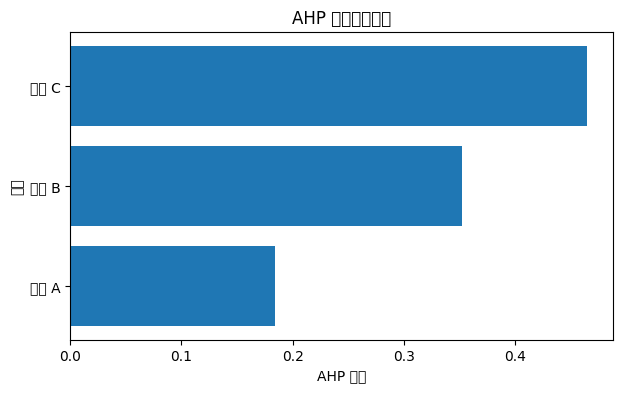

In [8]:
import matplotlib.pyplot as plt

ranking_plot = ranking.sort_values("總分", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(ranking_plot["方案"], ranking_plot["總分"])
plt.xlabel("AHP 總分")
plt.ylabel("方案")
plt.title("AHP 方案排序結果")
plt.show()


# 20. Python 實作二：使用既有 AHP 套件

Python 生態中可使用 `ahpy` 進行 AHP 計算。它可以處理成對比較資料，並輸出權重與一致性相關資訊。

若尚未安裝，先執行：

```python
%pip install ahpy
```

下面使用與前面相同的三個準則範例：

- 價格
- 續航力
- 健康監測功能

注意：不同套件對於「比較方向」與資料格式的定義可能不同。使用套件時，務必檢查輸入 pairwise comparison 的方向是否與研究問卷設計一致。


In [ ]:
# 如尚未安裝 ahpy，請取消下一行註解後執行。
# %pip install ahpy


In [ ]:
try:
    import ahpy

    # ahpy 使用 pairwise comparison dictionary。
    # 這裡的 key 是比較的兩個項目，value 是前者相對於後者的重要程度。
    comparisons = {
        ("價格", "續航力"): 1/3,
        ("價格", "健康監測功能"): 1/5,
        ("續航力", "健康監測功能"): 1/2,
    }

    criteria_compare = ahpy.Compare(
        name="智慧型手錶準則",
        comparisons=comparisons,
        precision=4,
        random_index="saaty"
    )

    print("準則權重：")
    print(criteria_compare.target_weights)

    print("\n一致性比率 CR：")
    print(criteria_compare.consistency_ratio)

except ImportError:
    print("尚未安裝 ahpy。請先執行：%pip install ahpy")


## 20.1 使用 `ahpy` 建立包含方案層的簡化模型

下面示範用 `ahpy` 分別建立：

1. 準則比較。
2. 價格準則下的方案比較。
3. 續航力準則下的方案比較。
4. 健康監測功能準則下的方案比較。

最後再將方案比較附加到準則比較之下，形成一個簡化的 AHP hierarchy。


In [ ]:
try:
    import ahpy

    criteria_compare = ahpy.Compare(
        "Criteria",
        {
            ("價格", "續航力"): 1/3,
            ("價格", "健康監測功能"): 1/5,
            ("續航力", "健康監測功能"): 1/2,
        },
        precision=4,
        random_index="saaty"
    )

    price_compare = ahpy.Compare(
        "價格",
        {
            ("方案 A", "方案 B"): 3,
            ("方案 A", "方案 C"): 5,
            ("方案 B", "方案 C"): 2,
        },
        precision=4,
        random_index="saaty"
    )

    battery_compare = ahpy.Compare(
        "續航力",
        {
            ("方案 A", "方案 B"): 1/4,
            ("方案 A", "方案 C"): 1/2,
            ("方案 B", "方案 C"): 3,
        },
        precision=4,
        random_index="saaty"
    )

    health_compare = ahpy.Compare(
        "健康監測功能",
        {
            ("方案 A", "方案 B"): 1/2,
            ("方案 A", "方案 C"): 1/5,
            ("方案 B", "方案 C"): 1/3,
        },
        precision=4,
        random_index="saaty"
    )

    criteria_compare.add_children([price_compare, battery_compare, health_compare])

    print("整體方案權重：")
    print(criteria_compare.target_weights)

except ImportError:
    print("尚未安裝 ahpy。請先執行：%pip install ahpy")


# 21. 小結

本 Notebook 將 AHP 的概念、數學推導與程式實作連接起來。

重點如下：

1. AHP 先將決策問題拆成目標、準則與方案。
2. 同一層級內的項目透過成對比較矩陣表示相對重要性。
3. 權重可透過幾何平均法或特徵向量法取得。
4. 最大特徵值、CI 與 CR 可用來檢查判斷矩陣的一致性。
5. Vanilla 版本有助於理解每一步數學計算。
6. 套件版本適合在熟悉概念後，用於較完整或較大型的研究資料處理。

在研究應用上，建議先用 vanilla 版本檢查小型範例是否合理，再使用套件或自行封裝函式處理正式資料。
